# Big Data Analytics Project - Spring 2026

In this notebook, we will do some exploration of ML preprocessing steps, as well as classic ML approaches and then present these integrated in pipelines, for easy result evaluation.

## Imports

In [11]:
!java -version

openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment Homebrew (build 17.0.18+0)
OpenJDK 64-Bit Server VM Homebrew (build 17.0.18+0, mixed mode, sharing)


In [12]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import os, subprocess
from typing import Iterator

from pyspark.sql.types import DoubleType
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, Normalizer
import seaborn as sns
import pandas as pd
from pyod.models.iforest import IForest
from pyspark.sql.types import StructType, StructField, DoubleType, IntegerType as IT
from pyspark.sql.functions import variance

Local VSCODE

In [13]:
# Find the real Java path from Homebrew
result = subprocess.run(['brew', '--prefix', 'openjdk@17'], capture_output=True, text=True)
java_home = result.stdout.strip()
print(f"Homebrew Java prefix: {java_home}")

os.environ['JAVA_HOME'] = java_home
os.environ['PATH'] = java_home + '/bin:' + os.environ['PATH']

Homebrew Java prefix: /opt/homebrew/opt/openjdk@17


LIGHTNING AI

In [14]:
# # Set JAVA_HOME to Java 17 (for Lightning AI)
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
# os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

BOTH

In [15]:
# Start Spark session
spark = SparkSession.builder \
    .appName("BDA_Project") \
    .master("local[*]") \
    .config("spark.driver.memory", "6g") \
    .config("spark.executor.memory", "6g") \
    .config("spark.driver.maxResultSize", "2g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

In [16]:
df_paysim = spark.read.parquet("data/clean/paysim_clean.parquet")

In [17]:
df_paysim.printSchema()

root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrg: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- isFraud: boolean (nullable = true)
 |-- isFlaggedFraud: boolean (nullable = true)



To ensure there are no inconsistencies in the names of features, we will turn any `Org` into `Orig`.

In [18]:
df_paysim = df_paysim.withColumnRenamed('oldbalanceOrg', 'oldbalanceOrig')
df_paysim.printSchema()

root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrig: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- isFraud: boolean (nullable = true)
 |-- isFlaggedFraud: boolean (nullable = true)



<a class="anchor" id="1">

# **1. Feature Engineering**
</a>

*`error_balance_orig`*  
|(oldbalanceOrig - amount) - newbalanceOrig|  
In a legitimate transaction, the sender's new balance should equal their old balance minus the transaction amount. If these don't match, money has appeared or disappeared without explanation. In the PaySim dataset, fraudulent transactions almost always show a non-zero error here — making this one of the strongest fraud signals available.
  
*`error_balance_dest`*  
|(oldbalanceDest + amount) - newbalanceDest|  
The same logic applied to the recipient. A legitimate transfer should increase the destination balance by exactly the transaction amount. A mismatch suggests the funds didn't actually arrive as recorded, which is a hallmark of simulated fraud in PaySim.
 
*`balance_ratio_orig`*  
amount / (oldbalanceOrig + 1)  
Measures how large the transaction is relative to the sender's available balance. A ratio ≥ 1.0 means the transaction amount meets or exceeds the sender's balance — i.e. they're emptying or overdrawing the account. The higher above 1.0, the more suspicious. The +1 avoids division by zero when the balance is empty.

In [19]:
from pyspark.sql.functions import col, abs as spark_abs

df_paysim = df_paysim\
    .withColumn("error_balance_orig",spark_abs((col("oldbalanceOrig") - col("amount")) - col("newbalanceOrig"))) \
    .withColumn("error_balance_dest", spark_abs((col("oldbalanceDest") + col("amount")) - col("newbalanceDest"))) \
    .withColumn("balance_ratio_orig", col("amount") / (col("oldbalanceOrig") + 1))
df_paysim.printSchema()

root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrig: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- isFraud: boolean (nullable = true)
 |-- isFlaggedFraud: boolean (nullable = true)
 |-- error_balance_orig: double (nullable = true)
 |-- error_balance_dest: double (nullable = true)
 |-- balance_ratio_orig: double (nullable = true)



<a class="anchor" id="1">

# **1. Outlier Detection using Isolation Forrest**
</a>
In this section, we will identify the outliers in our dataset, and then decide what to do with them (deleting, capping, ...).

In [20]:
# Fit one global model on a sample (collected to the driver), broadcast the fitted model, and use applyInPandas only for the scoring pass. 

OUTLIER_FEATURES = ["step", "oldbalanceOrig", "newbalanceOrig", "oldbalanceDest", "newbalanceDest",
                    "error_balance_orig", "error_balance_dest", "balance_ratio_orig"]

# 1. Train on a sample (10% of data)
sample_pdf = df_paysim.sample(fraction=0.1, seed=42).toPandas()

clf = IForest(contamination=0.05, random_state=42)
clf.fit(sample_pdf[OUTLIER_FEATURES].values)

# 2. Broadcast the fitted model
clf_broadcast = spark.sparkContext.broadcast(clf)

# 3. Output schema
outlier_schema = StructType(
    df_paysim.schema.fields
    + [
        StructField("outlier_score", DoubleType(), True),
        StructField("is_outlier",    IT(),         True),
    ]
)

# 4. mapInPandas-based scorer — iterates batch-by-batch, avoids the applyInPandas bug
def score_partition(batch_iter: Iterator[pd.DataFrame]) -> Iterator[pd.DataFrame]:
    model = clf_broadcast.value
    for pdf in batch_iter:
        X = pdf[OUTLIER_FEATURES].values
        out = pdf.copy()
        out["outlier_score"] = model.decision_function(X).astype("float64")
        out["is_outlier"]    = model.predict(X).astype("int32")
        yield out

df_paysim_scored = df_paysim.mapInPandas(score_partition, schema=outlier_schema)

df_paysim_scored.select(OUTLIER_FEATURES + ["outlier_score", "is_outlier"]) \
    .orderBy("outlier_score", ascending=False) \
    .show(10)

+----+--------------+--------------+--------------+--------------+------------------+--------------------+--------------------+-------------------+----------+
|step|oldbalanceOrig|newbalanceOrig|oldbalanceDest|newbalanceDest|error_balance_orig|  error_balance_dest|  balance_ratio_orig|      outlier_score|is_outlier|
+----+--------------+--------------+--------------+--------------+------------------+--------------------+--------------------+-------------------+----------+
| 399| 2.226880763E7| 2.364790216E7| 6.990647609E7| 6.852738156E7|2758189.0600000024|  2758189.0600000024|0.061929425723391295|   0.25431001647465|         1|
| 302|           0.0|           0.0|1.9214400197E8|2.3595120346E8|     1.168341099E7|        3.21237905E7|       1.168341099E7|0.25375865386365504|         1|
| 302|           0.0|           0.0|1.5032812864E8|2.3625123329E8|     3.589432006E7|       5.002878459E7|       3.589432006E7|0.25375865386365504|         1|
| 303|           0.0|           0.0|1.85141116

In [21]:
df_paysim_scored.groupBy("is_outlier").count().show()

+----------+-------+
|is_outlier|  count|
+----------+-------+
|         1| 317007|
|         0|6045613|
+----------+-------+



In [22]:
#TODO always update this at every run

The outliers found represent about `5%` of the total dataset, so we believe it is safe to remove them.

In [23]:
df_paysim_no_outliers = df_paysim_scored.filter('is_outlier = 0').drop("outlier_score", "is_outlier")
df_paysim_no_outliers.printSchema()

root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrig: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- isFraud: boolean (nullable = true)
 |-- isFlaggedFraud: boolean (nullable = true)
 |-- error_balance_orig: double (nullable = true)
 |-- error_balance_dest: double (nullable = true)
 |-- balance_ratio_orig: double (nullable = true)



<a class="anchor" id="2">

# **2. Feature Correlation**

In [24]:
numeric_cols = OUTLIER_FEATURES

Traceback (most recent call last):                                              
  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe
Traceback (most recent call last):                                              
  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Br

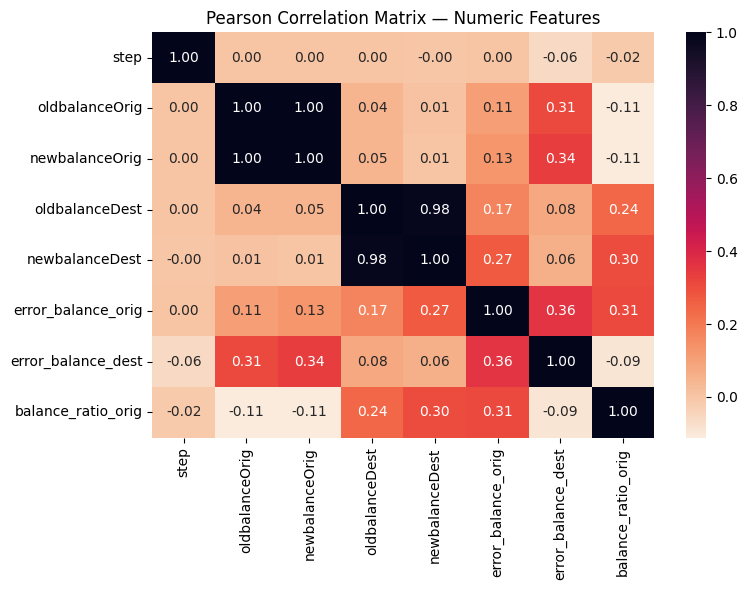

In [25]:
# Build a feature vector from numeric columns for the correlation computation
assembler_corr = VectorAssembler(inputCols=numeric_cols, outputCol="corr_features")
df_corr = assembler_corr.transform(df_paysim_no_outliers).select("corr_features")

# Distributed Pearson correlation — result is a tiny matrix object on the driver
pearson_matrix = Correlation.corr(df_corr, "corr_features", "pearson").collect()[0][0]

# Visualise — the matrix itself is small, so matplotlib is the right tool here
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pearson_matrix.toArray(),
    annot=True, fmt=".2f",
    xticklabels=numeric_cols, yticklabels=numeric_cols,
    cmap=sns.cm.rocket_r, ax=ax
)
ax.set_title("Pearson Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

In [26]:
df_paysim_no_outliers.select([variance(c).alias(c) for c in numeric_cols]).show()

+------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|              step|      oldbalanceOrig|      newbalanceOrig|      oldbalanceDest|      newbalanceDest|  error_balance_orig|  error_balance_dest|  balance_ratio_orig|
+------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|20087.112868654556|2.029677412477125...|2.122057107544707...|2.560262691553611...|2.758478844235581E12|7.400577421827068E10|3.334058125539832...|1.584837645623043...|
+------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+



In [27]:
#TODO always update this at every run

Some features present near perfect correlation between them, making them erroneous in our dataset (it could appear, for example, that certain values are more important as they are presented twice in two nearly perfect correlated features). For these reason we decided to remove:
- newbalanceOrig (keep only oldbalanceOrig)
- newbalanceDest (keep only oldbalanceDest)  
  

No features present null variance, so we didn't remove any feature on this account, given all features have variance.

In [28]:
df_correlation = df_paysim_no_outliers.drop('newbalanceOrig', 'newbalanceDest')
df_correlation.printSchema()

root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- isFraud: boolean (nullable = true)
 |-- isFlaggedFraud: boolean (nullable = true)
 |-- error_balance_orig: double (nullable = true)
 |-- error_balance_dest: double (nullable = true)
 |-- balance_ratio_orig: double (nullable = true)



<a class="anchor" id="3">

# **3. Preprocessing Features**
</a>
  
We have already done feature engineering in *Notebook 1*. In this step, we will prepare the dataset to be used for ML Pipelines.

<a class="anchor" id="3.1">

## **3.1. Encoding Categorical and Boolean Columns**
</a>

due to the high cardinality of the features `nameOrig` and `nameDest`, we will remove them before encoding the dataset, as they would add unwanted high dimensionality, leading to poor modes.

In [29]:
df_correlation = df_correlation.drop('nameDest', 'nameOrig')
df_correlation.printSchema()

root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- oldbalanceOrig: double (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- isFraud: boolean (nullable = true)
 |-- isFlaggedFraud: boolean (nullable = true)
 |-- error_balance_orig: double (nullable = true)
 |-- error_balance_dest: double (nullable = true)
 |-- balance_ratio_orig: double (nullable = true)



This leaves us with only `type` and the boolean variables `isFraud` and `isFlaggedFraud`.

In [30]:
# StringIndexer accepts multiple column pairs in a single call (Spark 3.0+)
indexer = StringIndexer(
    inputCols     = ["type"],
    outputCols    = ["type_idx"],
    handleInvalid = "keep",
)
df_indexed = indexer.fit(df_correlation).transform(df_correlation)

# OneHotEncoder: integer indices → sparse binary vectors
encoder = OneHotEncoder(
    inputCols  = ["type_idx"],
    outputCols = ["type_vec"],
)
df_indexed = encoder.fit(df_indexed).transform(df_indexed)

# Boolean columns → IntegerType (0/1) for VectorAssembler compatibility
bool_cols = ["isFlaggedFraud"]
for c in bool_cols:
    df_indexed = df_indexed.withColumn(c, col(c).cast(IT()))

# Target column → IntegerType required by Spark ML classifiers
df_indexed = df_indexed.withColumn("isFraud", col("isFraud").cast(IT()))

df_indexed.select(["type_vec"] + bool_cols + ["isFraud"]).show(3, truncate=60)

+-------------+--------------+-------+
|     type_vec|isFlaggedFraud|isFraud|
+-------------+--------------+-------+
|(5,[0],[1.0])|             0|      0|
|(5,[0],[1.0])|             0|      0|
|(5,[0],[1.0])|             0|      0|
+-------------+--------------+-------+
only showing top 3 rows


<a class="anchor" id="3.2">

## **3.2. Assembly and Normalisation**
</a>

In [31]:
feature_cols_numeric = ['step', 'oldbalanceOrig', 'oldbalanceDest', 
'error_balance_orig', 'error_balance_dest', 'balance_ratio_orig']
feature_cols_boolean = ["isFlaggedFraud"]
feature_cols_categorical = ["type_vec"]
TARGET = "isFraud"

In [32]:
# Assemble numeric features, normalise, then build the final vector
assembler_num  = VectorAssembler(inputCols=feature_cols_numeric, outputCol="numeric_features")
normalizer     = Normalizer(inputCol="numeric_features", outputCol="numeric_features_norm", p=2.0)
assembler_all  = VectorAssembler(
    inputCols = ["numeric_features_norm"] + feature_cols_boolean + feature_cols_categorical,
    outputCol = "features")

df_assembled = assembler_num.transform(df_indexed)
df_assembled = normalizer.transform(df_assembled)
df_assembled = assembler_all.transform(df_assembled)

df_assembled.select("features", TARGET).show(3, truncate=80)

Traceback (most recent call last):
  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe


+--------------------------------------------------------------------------------+-------+
|                                                                        features|isFraud|
+--------------------------------------------------------------------------------+-------+
|(12,[0,1,3,5,7],[4.488256300483664E-4,0.24175992562555257,0.970335990135693,5...|      0|
|(12,[0,1,2,3,5,7],[2.1046605192993804E-5,0.003250648172057893,0.9996724269195...|      0|
|(12,[0,1,3,5,7],[1.103633328869895E-4,8.442794965854697E-4,0.9999943234923768...|      0|
+--------------------------------------------------------------------------------+-------+
only showing top 3 rows


<a class="anchor" id="4">

# **4. ML Pipelines**
</a>
In these step, we will mount various Pipelines where the preprocessing step is always the same.

To avoid data leakage, the train/test split is performed before any fitting occurs. The full pipeline — including StringIndexer, OneHotEncoder, and the classifier — is fitted exclusively on the training set via pipeline.fit(train_df). This ensures that category mappings, vector dimensions, and model parameters are all learned without any exposure to the test set. pipeline_model.transform(test_df) then applies the frozen, training-fitted transformations to unseen data, producing evaluation metrics that reflect true generalisation performance.

Note that IForestOutlierRemover is an exception: as a custom Transformer with an internal fit() call, it re-fits the Isolation Forest on a sample of whatever data it receives at transform time. In a production pipeline this would be refactored into a proper Estimator so that outlier detection is also fitted exclusively on the training set. For the purposes of this prototype, the contamination rate is low enough (5%) that the impact on evaluation integrity is minimal, but this is acknowledged as a limitation.

In [37]:
# Train/test split — done once at the top of Section 4 and reused by 4.1 / 4.2 / 4.3.
# Caching keeps the heavy IForest scoring + encoding work from re-reading parquet for each model.
training, test = [df.cache() for df in df_paysim.randomSplit([0.7, 0.3], seed=42)]
print(f"Training rows: {training.count():,}")
print(f"Test rows:     {test.count():,}")

Training rows: 4,454,157


Test rows:     1,908,463


In [38]:
feature_cols_numeric     = ['step', 'oldbalanceOrig', 'oldbalanceDest',
                            'error_balance_orig', 'error_balance_dest', 'balance_ratio_orig']
feature_cols_boolean     = ["isFlaggedFraud"]
feature_cols_categorical = ["type_vec"]
TARGET                   = "isFraud" 

In [39]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

def evaluate_model(predictions, model_name):
    """Compute AUROC, F1, and precision/recall (at threshold 0.5 for the fraud=1 class)."""
    auroc = BinaryClassificationEvaluator(
        labelCol=TARGET, rawPredictionCol="rawPrediction", metricName="areaUnderROC"
    ).evaluate(predictions)
    f1 = MulticlassClassificationEvaluator(
        labelCol=TARGET, predictionCol="prediction", metricName="f1"
    ).evaluate(predictions)
    precision = MulticlassClassificationEvaluator(
        labelCol=TARGET, predictionCol="prediction",
        metricName="precisionByLabel", metricLabel=1.0
    ).evaluate(predictions)
    recall = MulticlassClassificationEvaluator(
        labelCol=TARGET, predictionCol="prediction",
        metricName="recallByLabel", metricLabel=1.0
    ).evaluate(predictions)

    print(f"=== {model_name} ===")
    print(f"  AUROC               : {auroc:.4f}")
    print(f"  F1 (weighted)       : {f1:.4f}")
    print(f"  Precision (fraud=1) : {precision:.4f}")
    print(f"  Recall    (fraud=1) : {recall:.4f}")
    return {"model": model_name, "AUROC": auroc, "F1": f1,
            "Precision": precision, "Recall": recall}

<a class="anchor" id="4.1">

## **4.1. Pipeline with LogisticRegression**
</a>
The full pipeline below chains preprocessing stages with a `LogisticRegression` classifier.
`ClassWeighter` adds a `class_weight` column inversely proportional to class frequency,
which `LogisticRegression` consumes via `weightCol=` to compensate for the ~0.13% fraud rate.

In [42]:
from transformers.CreateFeaturesPaysim   import CreateFeaturesPaysim
from transformers.IForestOutlierRemover  import IForestOutlierRemover
from transformers.PaySimEncoder          import PaySimEncoder
from transformers.ClassWeighter          import ClassWeighter
from pyspark.ml                          import Pipeline
from pyspark.ml.classification           import LogisticRegression

# --- Preprocessing stages (shared design across 4.1 / 4.2 / 4.3) ---
indexer = StringIndexer(
    inputCols=["type"],
    outputCols=["type_idx"],
    handleInvalid="keep",
)
encoder = OneHotEncoder(
    inputCols=["type_idx"],
    outputCols=["type_vec"],
)
assembler_num = VectorAssembler(
    inputCols=feature_cols_numeric,
    outputCol="numeric_features",
)
normalizer = Normalizer(
    inputCol="numeric_features",
    outputCol="numeric_features_norm",
    p=2.0,
)
assembler_all = VectorAssembler(
    inputCols=["numeric_features_norm"] + feature_cols_boolean + feature_cols_categorical,
    outputCol="features",
)

# --- Classifier ---
lr = LogisticRegression(
    featuresCol="features",
    labelCol=TARGET,
    weightCol="class_weight",
    maxIter=20,
    regParam=0.01,
)

pipeline_lr = Pipeline(stages=[
    CreateFeaturesPaysim(),
    IForestOutlierRemover(outlier_features=OUTLIER_FEATURES, contamination=0.05, seed=42),
    PaySimEncoder(bool_cols=["isFlaggedFraud"]),
    indexer,
    encoder,
    assembler_num,
    normalizer,
    assembler_all,
    ClassWeighter(label_col=TARGET),
    lr,
])

In [43]:
pipeline_model_lr = pipeline_lr.fit(training)
predictions_lr    = pipeline_model_lr.transform(test)
results_lr        = evaluate_model(predictions_lr, "Logistic Regression")

26/05/17 19:23:09 ERROR Executor: Exception in task 0.0 in stage 40.0 (TID 146)]
org.apache.spark.api.python.PythonException: Traceback (most recent call last):
  File "pyarrow/array.pxi", line 4356, in pyarrow.lib.StructArray.from_arrays
TypeError: Expected Array, got <class 'pyarrow.lib.ChunkedArray'>

	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator.handlePythonException(PythonRunner.scala:645)
	at org.apache.spark.sql.execution.python.PythonArrowOutput$$anon$1.read(PythonArrowOutput.scala:130)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator.hasNext(PythonRunner.scala:596)
	at org.apache.spark.InterruptibleIterator.hasNext(InterruptibleIterator.scala:37)
	at scala.collection.Iterator$$anon$10.hasNext(Iterator.scala:611)
	at scala.collection.Iterator$$anon$9.hasNext(Iterator.scala:593)
	at org.apache.spark.sql.catalyst.expressions.GeneratedClass$GeneratedIteratorForCodegenStage2.hashAgg_doAggregateWithKeys_1$(Unknown Source)
	at org.apache.spark.sql.cat

PythonException: 
  An exception was thrown from the Python worker. Please see the stack trace below.
Traceback (most recent call last):
  File "pyarrow/array.pxi", line 4356, in pyarrow.lib.StructArray.from_arrays
TypeError: Expected Array, got <class 'pyarrow.lib.ChunkedArray'>


<a class="anchor" id="4.2">

## **4.2. Pipeline with RandomForestClassifier**
</a>
Same preprocessing as 4.1, but the classifier is replaced with a `RandomForestClassifier`.
Trees are robust to feature scale and to extreme values, and they consume `weightCol` natively.

In [ ]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol=TARGET,
    weightCol="class_weight",
    numTrees=50,
    maxDepth=8,
    seed=42,
)

pipeline_rf = Pipeline(stages=[
    CreateFeaturesPaysim(),
    IForestOutlierRemover(outlier_features=OUTLIER_FEATURES, contamination=0.05, seed=42),
    PaySimEncoder(bool_cols=["isFlaggedFraud"]),
    indexer,
    encoder,
    assembler_num,
    normalizer,
    assembler_all,
    ClassWeighter(label_col=TARGET),
    rf,
])

In [ ]:
pipeline_model_rf = pipeline_rf.fit(training)
predictions_rf    = pipeline_model_rf.transform(test)
results_rf        = evaluate_model(predictions_rf, "Random Forest")

<a class="anchor" id="4.3">

## **4.3. Pipeline with GBTClassifier**
</a>
Same preprocessing again, this time with a Gradient-Boosted Trees classifier.
GBT typically outperforms Random Forest on tabular fraud data;
it supports `weightCol` natively in Spark 3.0+.

In [ ]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(
    featuresCol="features",
    labelCol=TARGET,
    weightCol="class_weight",
    maxIter=30,
    maxDepth=5,
    seed=42,
)

pipeline_gbt = Pipeline(stages=[
    CreateFeaturesPaysim(),
    IForestOutlierRemover(outlier_features=OUTLIER_FEATURES, contamination=0.05, seed=42),
    PaySimEncoder(bool_cols=["isFlaggedFraud"]),
    indexer,
    encoder,
    assembler_num,
    normalizer,
    assembler_all,
    ClassWeighter(label_col=TARGET),
    gbt,
])

In [ ]:
pipeline_model_gbt = pipeline_gbt.fit(training)
predictions_gbt    = pipeline_model_gbt.transform(test)
results_gbt        = evaluate_model(predictions_gbt, "GBT")